# Residual Stream Dynamics: 

Eric T. Wolf
University of Colorado
Laboratory for Atmospheric and Space Physics

## Purpose

Explore the relationship between the geometric structure of the residual stream


Semantically rich (*base*) prompts produce higher geometric entropy in the residual stream than ambiguous (*contrast*) prompts — yet yield *more certain* next-token predictions (lower logit lens entropy). This anti-correlation is consistent across GPT-2 and Pythia model families and scales with model size.

The finding implies that base prompts load more activation energy into high-singular-value directions of the unembedding matrix W_U, producing confident predictions despite greater total geometric spread. The orthogonal complement carries structured information invisible to the unembedding — its role is examined in `02_ablation_causal.ipynb`.

## Corpus

50 prompt pairs (25 base / 25 contrast) drawn from `corpus/base_vs_contrast_n50.json`. Each pair shares a category (e.g. *pattern*, *factual*, *syntactic*) with the base prompt having a clear, semantically grounded continuation and the contrast prompt being genuinely ambiguous.

All entropy values are Shannon entropy (Rényi α=1) at the **final token position**, hook `resid_post`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from npz_utils import load_entropy_npz, get_final_token_profiles
from notebook_plots import (
    plot_entropy_profiles,
    plot_paired_difference,
    plot_scaling_summary,
    get_param_count,
)

FIGURES_DIR = Path('../figures/notebooks')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path('../data')

%matplotlib inline

## 1. Single model deep-dive: GPT-2 Small

We begin with GPT-2 small (124M parameters, 12 layers) to establish the core finding before examining scaling behavior.

The two panels below show mean entropy ± 95% CI across all 25 base and 25 contrast prompts as a function of fractional layer depth (0 = embedding, 1 = final layer):

- **Left**: residual stream entropy (energy normalization) — geometric spread of activations in d_model space
- **Right**: logit lens entropy — uncertainty of next-token prediction when unembedding at each layer

The anti-correlation is immediate: base prompts are geometrically *more* spread (left panel) yet produce *more certain* predictions (right panel).

In [2]:
# Load GPT-2 small
data_sm = load_entropy_npz(DATA_DIR / 'entropy_records_gpt2-small_base_vs_contrast_n50.npz')

# Residual stream profiles
base_resid_sm, _, _, _     = get_final_token_profiles(data_sm, norm_key='energy',     role='base')
contrast_resid_sm, _, _, _ = get_final_token_profiles(data_sm, norm_key='energy',     role='contrast')

# Logit lens profiles
base_logit_sm, _, _, _     = get_final_token_profiles(data_sm, norm_key='logit_lens', role='base')
contrast_logit_sm, _, _, _ = get_final_token_profiles(data_sm, norm_key='logit_lens', role='contrast')

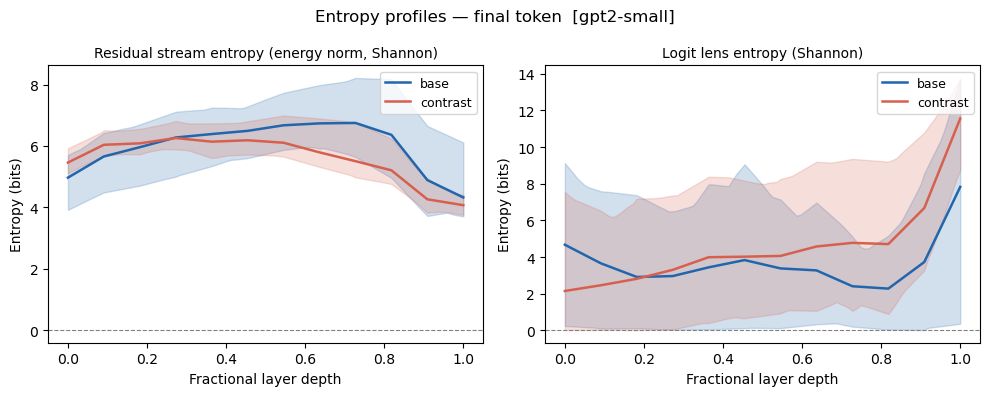

In [3]:
fig, axes = plot_entropy_profiles(
    base_resid_sm, contrast_resid_sm,
    base_logit_sm, contrast_logit_sm,
    model_name='gpt2-small',
    save_path=FIGURES_DIR / 'entropy_profiles_gpt2-small.png',
)
plt.show()

### Paired difference

The signed difference (base − contrast) makes the anti-correlation explicit. Positive values indicate base > contrast; negative indicate base < contrast.

Note the sign flip between residual stream (positive, peaks around layer 8) and logit lens (negative, grows monotonically toward the final layer). This is the central empirical result.

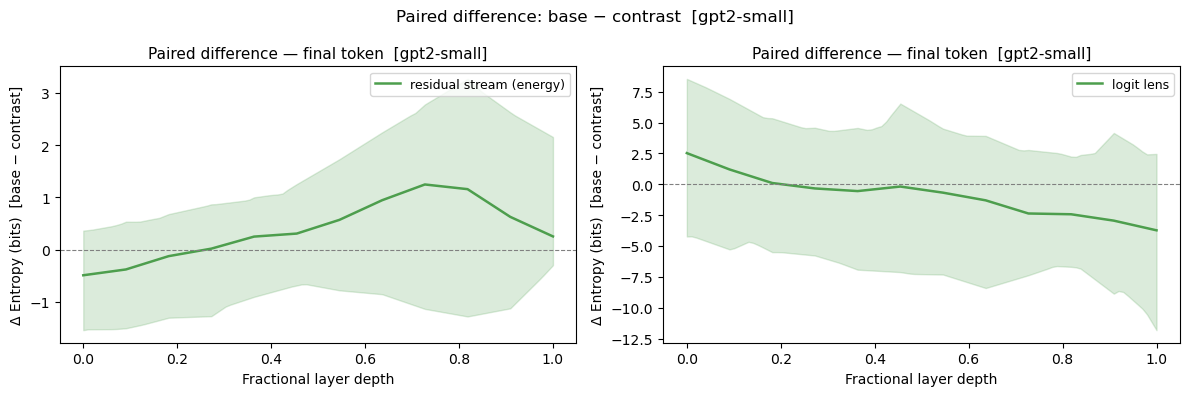

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

plot_paired_difference(
    base_resid_sm, contrast_resid_sm,
    model_name='gpt2-small',
    label='residual stream (energy)',
    ax=ax1,
)

plot_paired_difference(
    base_logit_sm, contrast_logit_sm,
    model_name='gpt2-small',
    label='logit lens',
    ax=ax2,
)

fig.suptitle('Paired difference: base − contrast  [gpt2-small]', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'paired_difference_gpt2-small.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. W_U subspace structure

Why does greater geometric spread in the residual stream produce more certain predictions?

The unembedding matrix W_U (shape [d_model, vocab_size]) maps residual stream vectors to logits. Its singular value spectrum determines which directions in residual stream space have the most influence on token predictions.

The bar chart below shows the cumulative explained variance of W_U by its top-k singular directions for GPT-2 small (d_model=768). A low-rank structure would show a sharp elbow — most variance explained by a small number of directions. Instead the spectrum is remarkably flat: ~600 dimensions are needed to explain 92% of variance.

This means there is no natural low-rank prediction subspace. The r∥/r⊥ decomposition is better understood as a **high-influence vs. low-influence spectrum** rather than a clean partition.

In [10]:
# W_U explained variance — displayed from pre-computed figure
# Source: workflows/wu_subspace_analysis.py
# To regenerate: python workflows/wu_subspace_analysis.py --model gpt2-small --corpus base_vs_contrast_n50.json
#from IPython.display import Image
#Image('../figures/notebooks/wu_explained_variance_gpt2-small.png')


## 3. Replication across model families and scales

The anti-correlation replicates across GPT-2 (small, medium, large, XL) and Pythia (160m, 1b, 2.8b, 6.9b). Below we show the paired difference profiles for all models on shared fractional-depth axes, allowing direct visual comparison despite differing layer counts.

In [6]:
MODELS = [
    'gpt2-small', 'gpt2-medium', 'gpt2-large', 'gpt2-xl',
    'pythia-160m', 'pythia-1b', 'pythia-2.8b', 'pythia-6.9b',
]

model_data = {}
for model in MODELS:
    npz_path = DATA_DIR / f'entropy_records_{model}_base_vs_contrast_n50.npz'
    d = load_entropy_npz(npz_path)
    model_data[model] = {
        'base_resid':     get_final_token_profiles(d, norm_key='energy',     role='base')[0],
        'contrast_resid': get_final_token_profiles(d, norm_key='energy',     role='contrast')[0],
        'base_logit':     get_final_token_profiles(d, norm_key='logit_lens', role='base')[0],
        'contrast_logit': get_final_token_profiles(d, norm_key='logit_lens', role='contrast')[0],
    }

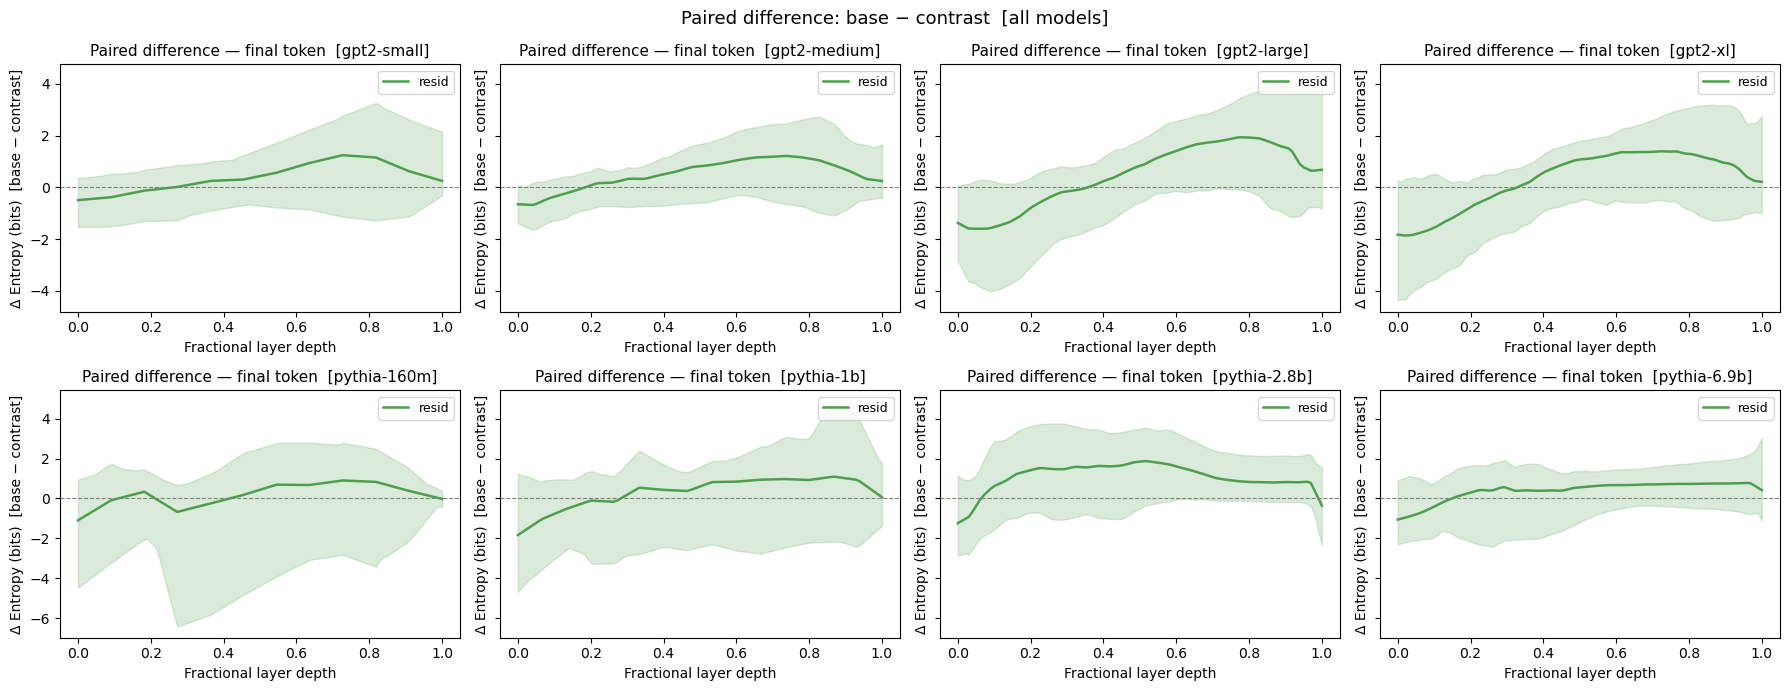

In [7]:
# Multi-model paired difference grid
# Rows: GPT-2 family, Pythia family
# Columns: residual stream, logit lens

gpt2_models    = [m for m in MODELS if 'gpt2'   in m]
pythia_models  = [m for m in MODELS if 'pythia' in m]

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey='row')
fig.suptitle('Paired difference: base − contrast  [all models]', fontsize=13)

for col, model in enumerate(gpt2_models):
    md = model_data[model]
    plot_paired_difference(md['base_resid'], md['contrast_resid'],
                           model_name=model, label='resid', ax=axes[0, col])

for col, model in enumerate(pythia_models):
    md = model_data[model]
    plot_paired_difference(md['base_resid'], md['contrast_resid'],
                           model_name=model, label='resid', ax=axes[1, col])

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'paired_difference_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Scaling summary

The peak paired difference (base − contrast) in both residual stream and logit lens entropy plotted against model parameter count. If the anti-correlation strengthens or persists with scale, it suggests the phenomenon is not an artifact of small model capacity.

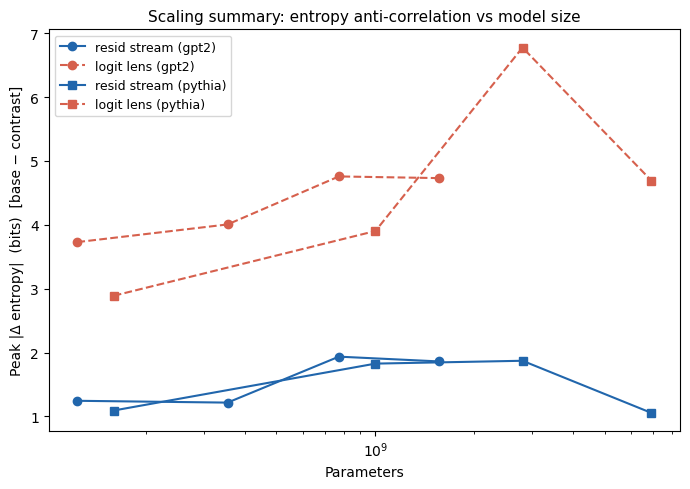

In [8]:
from notebook_plots import _mean_and_ci

model_results = []
for model in MODELS:
    md = model_data[model]
    family = 'gpt2' if 'gpt2' in model else 'pythia'

    _, resid_mean, _, _ = _mean_and_ci(
        [b - c for b, c in zip(md['base_resid'], md['contrast_resid'])]
    )
    _, logit_mean, _, _ = _mean_and_ci(
        [b - c for b, c in zip(md['base_logit'], md['contrast_logit'])]
    )

    model_results.append({
        'model_name':  model,
        'family':      family,
        'peak_resid':  float(np.max(np.abs(resid_mean))),
        'peak_logit':  float(np.max(np.abs(logit_mean))),
    })

fig, ax = plot_scaling_summary(
    model_results,
    save_path=FIGURES_DIR / 'scaling_summary.png',
)
plt.show()

## Summary

- Base prompts consistently exhibit higher residual stream entropy and lower logit lens entropy than contrast prompts across all tested models and scales.
- The W_U singular value spectrum is flat (high-rank), meaning there is no clean partition between a prediction subspace and an orthogonal complement — the r∥/r⊥ decomposition is best understood as a high-influence vs. low-influence spectrum.
- The causal role of the low-influence complement is examined in `02_ablation_causal.ipynb`.

**Open questions**: Does the anti-correlation strengthen with scale? What does the orthogonal complement encode? See `FutureWork.md`.